# **RNN training procedure**


In [ ]:
#Clone the GitHub repository

!git clone https://github.com/jgrk28/kalnet.git
%cd kalnet
%pip install -e .

In [ ]:
#Imports

import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path

## RNN with batch_size = 10

In [ ]:
#make sure you are in the /content/kalnet directory when running this
from paper_pytorch.train import (
    DEFAULT_CHECKPOINT,
    batch_to_tensors,
    load_checkpoint,
    train,
)

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

SEED = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CHECKPOINT = REPO_ROOT / DEFAULT_CHECKPOINT
print(f"device={DEVICE}, checkpoint={CHECKPOINT}")
if DEVICE == "cpu":
    print("Note: CUDA unavailable here; full 50k run will be slower on CPU.")

device=cpu, checkpoint=/content/kalnet/kalman_checkpoints/kf_allgains.pt
Note: CUDA unavailable here; full 50k run will be slower on CPU.


In [ ]:
# Skip if there is already a trained network saved
result = train(
    max_iter=50_001,
    test_iter=2_501,
    batch_size=10,
    log_every=500,
    lr=2e-4,
    tr_cond="all_gains",
    test_cond="all_gains",
    seed=SEED,
    device=DEVICE,
    save_path=CHECKPOINT,
)
print(
    f"test Fractional RMSE={result['frac_rmse_test']:.4f}, "
    f"saved {CHECKPOINT.resolve()}"
)

Fractional RMSE learning curve

/content/kalnet/paper_pytorch


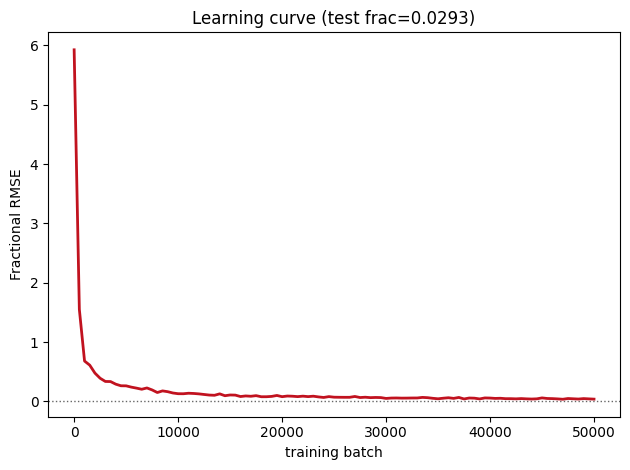

{'n_in': 50,
 'n_hid': 200,
 'stim_dur': 25,
 'batch_size': 10,
 'lr': 0.0002,
 'tr_cond': 'all_gains',
 'test_cond': 'all_gains',
 'seed': 0,
 'log_every': 500,
 'max_iter': 50001}

In [ ]:
%cd paper_pytorch # make sure you are in the /content/kalman/paper_pytorch directory to run this cell
loaded = load_checkpoint("networks/kf_allgains_def.pt", device=DEVICE)
model = loaded["model"]
cfg = loaded["config"]
frac = loaded["frac_rmse_vec"]
log_every = cfg.get("log_every", 500)
batches = np.arange(len(frac)) * log_every

fig, ax = plt.subplots()
ax.plot(batches, frac, color="#c1121f", lw=2)
ax.axhline(0.0, color="#666666", lw=1, ls=":")
ax.set_xlabel("training batch")
ax.set_ylabel("Fractional RMSE")
ax.set_title(
    f"Learning curve (test frac={loaded['frac_rmse_test']:.4f})"
)
fig.tight_layout()
plt.show()
cfg

Weights representation

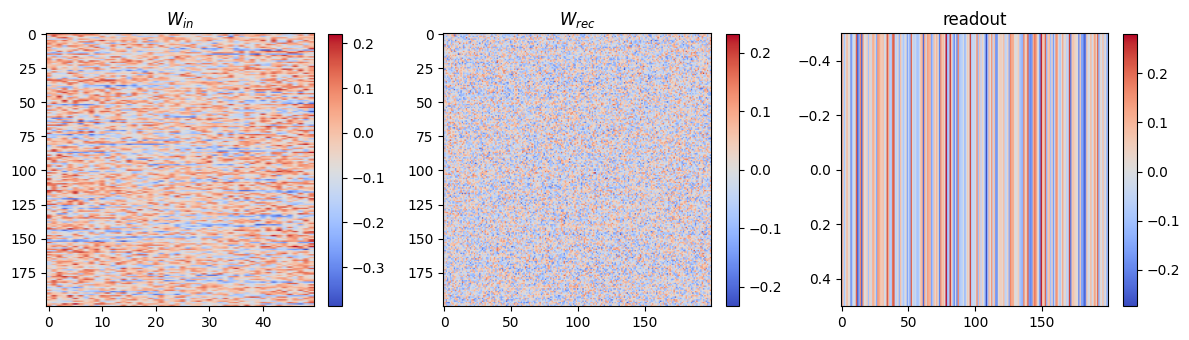

In [ ]:
W_in = model.W_in.weight.detach().cpu().numpy()      # (n_hid, n_in)
W_rec = model.W_rec.weight.detach().cpu().numpy()    # (n_hid, n_hid)
w_out = model.readout.weight.detach().cpu().numpy()  # (1, n_hid)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, mat, title in zip(
    axes,
    [W_in, W_rec, w_out],
    ["$W_{in}$", "$W_{rec}$", "readout"],
):
    im = ax.imshow(mat, aspect="auto", cmap="coolwarm")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()

Test network performance

In [ ]:
checkpoint = torch.load("networks/kf_allgains_def.pt", map_location="cpu", weights_only=False)
net = KalmanRNN(n_in=checkpoint["config"]["n_in"], n_hid=checkpoint["config"]["n_hid"], n_out=1)
net.load_state_dict(checkpoint["state_dict"])
net.eval()

test_task = KalmanFilteringTask(batch_size=2000, tr_cond="all_gains", seed=999)
batch = test_task.sample(include_internals=True)

x = torch.from_numpy(batch.input)
y_true = torch.from_numpy(batch.target)
y_opt = torch.from_numpy(batch.opt_mean)

with torch.no_grad():
    y_hat = net(x)

rmse_net = torch.sqrt(torch.mean((y_hat - y_true) ** 2)).item()
rmse_opt = torch.sqrt(torch.mean((y_opt - y_true) ** 2)).item()
frac_rmse = 100 * (rmse_net - rmse_opt) / rmse_opt

print(f"Net RMSE:        {rmse_net:.4f}")
print(f"Optimal RMSE:    {rmse_opt:.4f}")
print(f"Fractional RMSE: {frac_rmse:.2f}%")

Net RMSE:        0.5113
Optimal RMSE:    0.4487
Fractional RMSE: 13.93%


## RNN with batch=100

In [ ]:
#Use vectorized version of the task and train scripts for speed purposes
#Make sure you are in the /content/kalnet/paper_pytorch directory when training the vectorized network

from task_vec import KalmanFilteringTask
from train_vec import train

In [ ]:
# Skip if there is already a trained network saved
result = train(batch_size=100, max_iter=20000, save_path="kalman_checkpoints/kf_allgains_100.pt")

[Errno 2] No such file or directory: 'paper_pytorch'
/content/kalnet/paper_pytorch


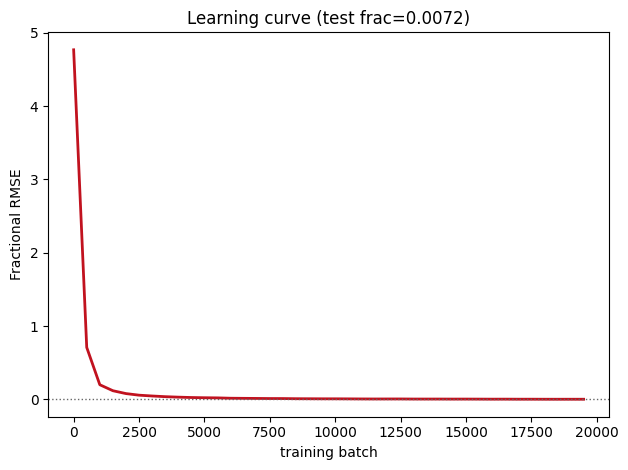

{'n_in': 50,
 'n_hid': 200,
 'stim_dur': 25,
 'batch_size': 100,
 'lr': 0.0003,
 'l2_penalty': 1e-06,
 'tr_cond': 'all_gains',
 'test_cond': 'all_gains',
 'seed': 0,
 'log_every': 500,
 'max_iter': 20000}

In [ ]:
loaded = load_checkpoint("networks/kf_allgains_batch100.pt", device=DEVICE)
model = loaded["model"]
cfg = loaded["config"]
frac = loaded["frac_rmse_vec"]
log_every = cfg.get("log_every", 500)
batches = np.arange(len(frac)) * log_every

fig, ax = plt.subplots()
ax.plot(batches, frac, color="#c1121f", lw=2)
ax.axhline(0.0, color="#666666", lw=1, ls=":")
ax.set_xlabel("training batch")
ax.set_ylabel("Fractional RMSE")
ax.set_title(
    f"Learning curve (test frac={loaded['frac_rmse_test']:.4f})"
)
fig.tight_layout()
plt.show()
cfg

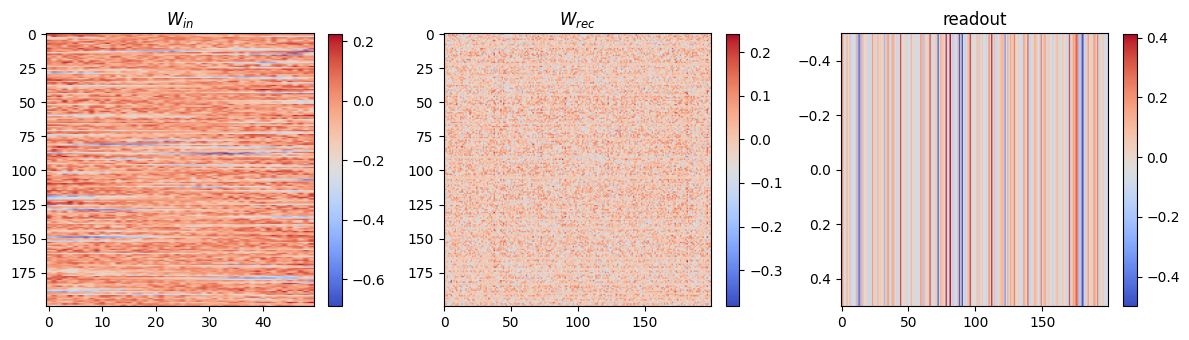

In [ ]:
W_in = model.W_in.weight.detach().cpu().numpy()      # (n_hid, n_in)
W_rec = model.W_rec.weight.detach().cpu().numpy()    # (n_hid, n_hid)
w_out = model.readout.weight.detach().cpu().numpy()  # (1, n_hid)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, mat, title in zip(
    axes,
    [W_in, W_rec, w_out],
    ["$W_{in}$", "$W_{rec}$", "readout"],
):
    im = ax.imshow(mat, aspect="auto", cmap="coolwarm")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()

Test network performance

In [ ]:
checkpoint = torch.load("networks/kf_allgains_batch100.pt", map_location="cpu", weights_only=False)
net = KalmanRNN(n_in=checkpoint["config"]["n_in"], n_hid=checkpoint["config"]["n_hid"], n_out=1)
net.load_state_dict(checkpoint["state_dict"])
net.eval()

test_task = KalmanFilteringTask(batch_size=2000, tr_cond="all_gains", seed=999)
batch = test_task.sample(include_internals=True)

with torch.no_grad():
    y_hat = net(batch.input)  # (batch, T, 1)

rmse_net = torch.sqrt(torch.mean((y_hat - batch.target) ** 2)).item()
rmse_opt = torch.sqrt(torch.mean((batch.opt_mean - batch.target) ** 2)).item()
frac_rmse = 100 * (rmse_net - rmse_opt) / rmse_opt

print(f"Net RMSE:        {rmse_net:.4f}")
print(f"Optimal RMSE:    {rmse_opt:.4f}")
print(f"Fractional RMSE: {frac_rmse:.2f}%")

Net RMSE:        0.4566
Optimal RMSE:    0.4531
Fractional RMSE: 0.78%
